# Notebook 04 - SHAP Analysis: Random Forest Interpretability

Uses shap.TreeExplainer - an exact, fast Shapley value algorithm optimized for tree-based models.

SHAP values answer: how much did each feature push this prediction away from the average prediction?

For multiclass RF, shap_values() returns an array of shape (n_samples, n_features, n_classes).
Index as shap_arr[:, :, class_idx] to get values for one class - shape (n_samples, n_features).

## Step 1 — Setup & Load Saved Artifacts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import shap
import joblib

# Load model and preprocessing objects saved in notebook 03
rf       = joblib.load('../models/random_forest.joblib')
ohe      = joblib.load('../models/ohe.joblib')
scaler   = joblib.load('../models/scaler.joblib')
metadata = joblib.load('../models/metadata.joblib')

FEATURES      = metadata['features']
NUMERIC_COLS  = metadata['numeric_cols']
BOOL_COLS     = metadata['bool_cols']
CAT_COLS      = metadata['cat_cols']
feature_names = metadata['feature_names']
CLASS_NAMES   = ['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']

print("Artifacts loaded successfully.")
print(f"Features ({len(feature_names)}): {feature_names}")

Artifacts loaded successfully.
Features (33): ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos', 'Is_Daylight', 'Junction', 'Traffic_Signal', 'Crossing', 'Stop', 'Station', 'Railway', 'road_type_Interstate Highway', 'road_type_Local Road', 'road_type_Major Arterial/Freeway', 'road_type_State Route', 'road_type_US Highway', 'Weather_Aggregated_Clear_or_Fair', 'Weather_Aggregated_Cloudy', 'Weather_Aggregated_Fog_Haze', 'Weather_Aggregated_Other_Rare_Conditions', 'Weather_Aggregated_Rain', 'Weather_Aggregated_Snow_Ice', 'Weather_Aggregated_Storm', 'Geo_Cluster_0', 'Geo_Cluster_1', 'Geo_Cluster_2', 'Geo_Cluster_3', 'Geo_Cluster_4']


## Step 2 — Prepare Test Data & Samples for SHAP

Two samples are created for different purposes:

- **`X_shap_natural`** — 300 rows sampled proportionally from the test set (mirrors real class distribution: ~83% Sev2, ~16% Sev3, <1% Sev1/Sev4). Used for **global feature importance** (Step 4) — reflects how the model behaves on realistic inputs.
- **`X_shap_balanced`** — 75 rows per class (300 total). Used for **per-class importance** (Steps 5–7) — ensures rare classes (Sev1, Sev4) have sufficient samples for stable per-class SHAP estimates.

Sample sizes are kept small deliberately: the RF was trained with `max_depth=20` which still produces complex trees. TreeExplainer complexity scales as O(T × L × D) per sample — larger samples increase runtime steeply.

Using the balanced sample for global importance would overweight rare classes ~140× relative to their true frequency, biasing the global ranking toward features that matter only for edge cases.

In [2]:
from sklearn.model_selection import train_test_split

# Load CYCLIC_COLS from metadata — saved by nb03 to guarantee exact match with training pipeline
CYCLIC_COLS = metadata['cyclic_cols']

# Recreate test set (same split as notebook 03)
df = pd.read_csv('../data/processed/CA_cleaned_geo.csv')

X = df[FEATURES].copy()
y = (df['Severity'] - 1).values

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- Feature assembly — must mirror nb03's assemble_features exactly ---
def cyclic_encode(X, col, period):
    vals = X[col].values
    sin  = np.sin(2 * np.pi * vals / period).astype(np.float32).reshape(-1, 1)
    cos  = np.cos(2 * np.pi * vals / period).astype(np.float32).reshape(-1, 1)
    return sin, cos

def assemble_features(X):
    parts = [scaler.transform(X[NUMERIC_COLS])]
    for col, period in CYCLIC_COLS:
        sin, cos = cyclic_encode(X, col, period)
        parts += [sin, cos]
    parts.append(X[BOOL_COLS].values.astype(np.float32))
    parts.append(ohe.transform(X[CAT_COLS]))
    return np.concatenate(parts, axis=1).astype(np.float32)

X_test_final = assemble_features(X_test)

assert X_test_final.shape[1] == rf.n_features_in_, (
    f"Feature mismatch: assembled {X_test_final.shape[1]} cols, "
    f"model expects {rf.n_features_in_}. Re-run notebook 03 to regenerate the model."
)

# --- Sample sizes deliberately small: RF has no max_depth, trees are 50+ levels deep ---
# TreeExplainer complexity: O(T × L × D) per sample — keep totals under ~500 rows
rng = np.random.default_rng(seed=42)

# Natural sample (proportional) — for global SHAP importance (Step 4)
natural_idx    = rng.choice(len(y_test), size=300, replace=False)
X_shap_natural = X_test_final[natural_idx]
y_shap_natural = y_test[natural_idx]

# Balanced sample (per class) — for per-class SHAP (Steps 5–7)
balanced_idx = []
for cls in range(4):
    cls_idx = np.where(y_test == cls)[0]
    n = min(75, len(cls_idx))
    balanced_idx.extend(rng.choice(cls_idx, n, replace=False))
X_shap_balanced = X_test_final[balanced_idx]
y_shap_balanced = y_test[balanced_idx]

print(f"X_test_final shape  : {X_test_final.shape}  (model expects {rf.n_features_in_} features ✓)")
print(f"\nNatural sample      : {X_shap_natural.shape[0]} rows")
print(f"  Class distribution: {dict(zip(*np.unique(y_shap_natural, return_counts=True)))}")
print(f"\nBalanced sample     : {X_shap_balanced.shape[0]} rows")
print(f"  Class distribution: {dict(zip(*np.unique(y_shap_balanced, return_counts=True)))}")
print(f"\nTotal SHAP rows     : {X_shap_natural.shape[0] + X_shap_balanced.shape[0]}")

X_test_final shape  : (341083, 33)  (model expects 33 features ✓)

Natural sample      : 300 rows
  Class distribution: {np.int64(0): np.int64(3), np.int64(1): np.int64(254), np.int64(2): np.int64(40), np.int64(3): np.int64(3)}

Balanced sample     : 300 rows
  Class distribution: {np.int64(0): np.int64(75), np.int64(1): np.int64(75), np.int64(2): np.int64(75), np.int64(3): np.int64(75)}

Total SHAP rows     : 600


## Step 3 — Compute SHAP Values

Two sets of SHAP values are computed — one per sample type.

In [3]:
explainer = shap.TreeExplainer(rf)

# shap_values shape: (n_samples, n_features, n_classes) = (300, 33, 4)
# check_additivity=False skips an expensive post-hoc verification pass
shap_natural  = np.array(explainer.shap_values(X_shap_natural,  check_additivity=False))
shap_balanced = np.array(explainer.shap_values(X_shap_balanced, check_additivity=False))

print(f"shap_natural  shape: {shap_natural.shape}")
print(f"shap_balanced shape: {shap_balanced.shape}")
print("Expected: (n_samples, n_features, n_classes) = (300, 33, 4)")

shap_natural  shape: (300, 33, 4)
shap_balanced shape: (300, 33, 4)


## Step 4 — Global Feature Importance (All Classes)

Uses the **natural sample** (proportional class distribution) so that the global ranking reflects how the model behaves on realistic inputs — not on an artificially balanced set.

Mean absolute SHAP value per feature, averaged across all 4 classes — shows which features matter most overall.

C:\Users\marga\AppData\Local\Temp\ipykernel_1716\1624538703.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis", ax=ax)


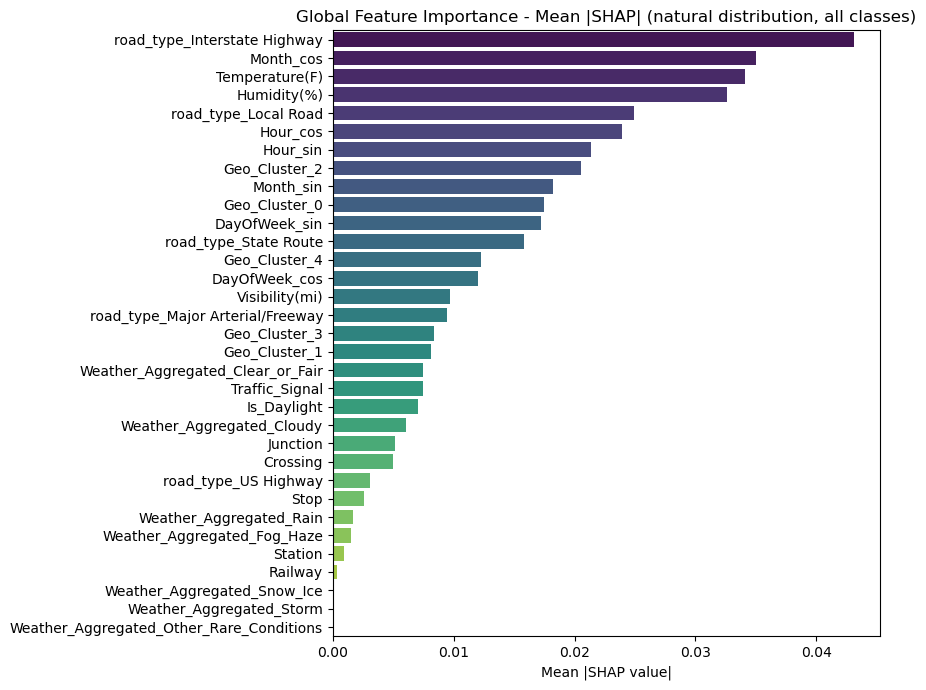

                                 feature  importance
            road_type_Interstate Highway    0.043118
                               Month_cos    0.034980
                          Temperature(F)    0.034136
                             Humidity(%)    0.032639
                    road_type_Local Road    0.024878
                                Hour_cos    0.023949
                                Hour_sin    0.021366
                           Geo_Cluster_2    0.020517
                               Month_sin    0.018212
                           Geo_Cluster_0    0.017457
                           DayOfWeek_sin    0.017242
                   road_type_State Route    0.015783
                           Geo_Cluster_4    0.012241
                           DayOfWeek_cos    0.012024
                          Visibility(mi)    0.009659
        road_type_Major Arterial/Freeway    0.009482
                           Geo_Cluster_3    0.008394
                           Geo_Cluster_1    0.

In [6]:
# shap_natural shape: (n_samples, n_features, n_classes) = (300, 33, 4)
# Mean |SHAP| per feature: average over samples (axis=0) then over classes (axis=1)
mean_abs_shap = np.mean(np.mean(np.abs(shap_natural), axis=0), axis=1)  # (n_features,)

importance_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": mean_abs_shap,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=importance_df, x="importance", y="feature", palette="viridis", ax=ax)
ax.set_title("Global Feature Importance - Mean |SHAP| (natural distribution, all classes)")
ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

## Step 5 — Per-Class Feature Importance

Uses the **balanced sample** (75 per class) — ensures stable SHAP estimates for Sev1 and Sev4, which would have only ~2 rows in the natural 300-row sample.

C:\Users\marga\AppData\Local\Temp\ipykernel_1716\388010017.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cls_df, x="importance", y="feature", palette="rocket", ax=ax)
C:\Users\marga\AppData\Local\Temp\ipykernel_1716\388010017.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cls_df, x="importance", y="feature", palette="rocket", ax=ax)
C:\Users\marga\AppData\Local\Temp\ipykernel_1716\388010017.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cls_df, x="importance", y="feature", palette="rocket", ax=ax)
C:\Users\marg

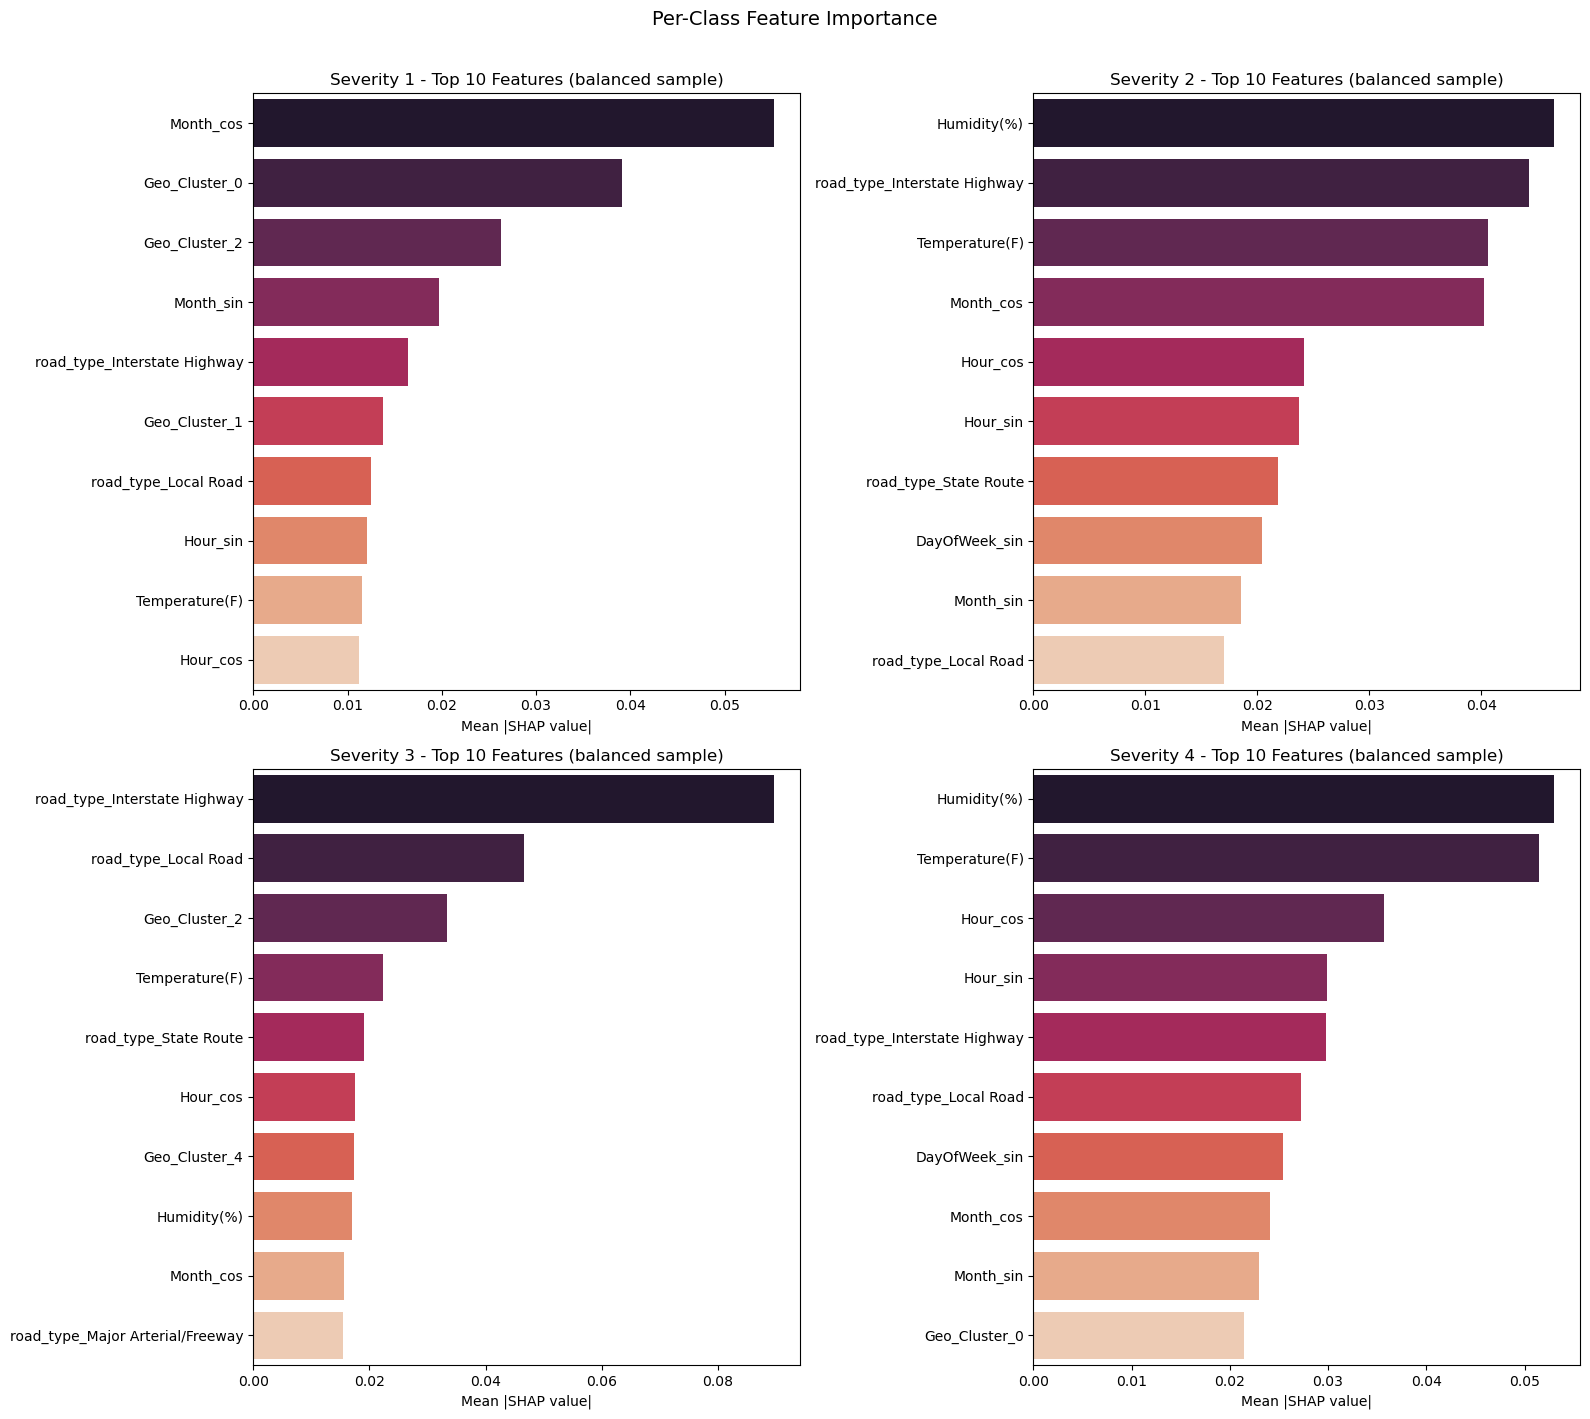

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for cls, ax in enumerate(axes.flat):
    # shap_balanced[:, :, cls] selects class cls -> shape (n_samples, n_features)
    mean_abs = np.mean(np.abs(shap_balanced[:, :, cls]), axis=0)
    cls_df = pd.DataFrame({"feature": feature_names, "importance": mean_abs})
    cls_df = cls_df.sort_values("importance", ascending=False).head(10)

    sns.barplot(data=cls_df, x="importance", y="feature", palette="rocket", ax=ax)
    ax.set_title(f"{CLASS_NAMES[cls]} - Top 10 Features (balanced sample)")
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_ylabel("")

plt.suptitle("Per-Class Feature Importance", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Step 6 — Beeswarm Summary Plot

Shows both the magnitude and direction of each feature's effect. Each dot is one sample — color = feature value (red = high, blue = low), x-axis = SHAP value (positive = pushes toward this class).

Severity 1  (balanced sample)


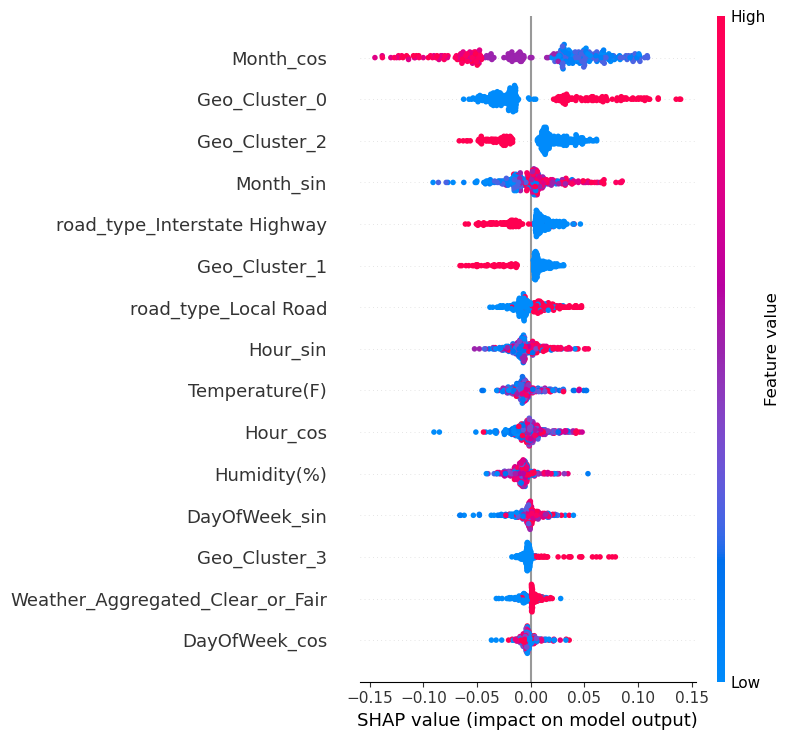

Severity 2  (balanced sample)


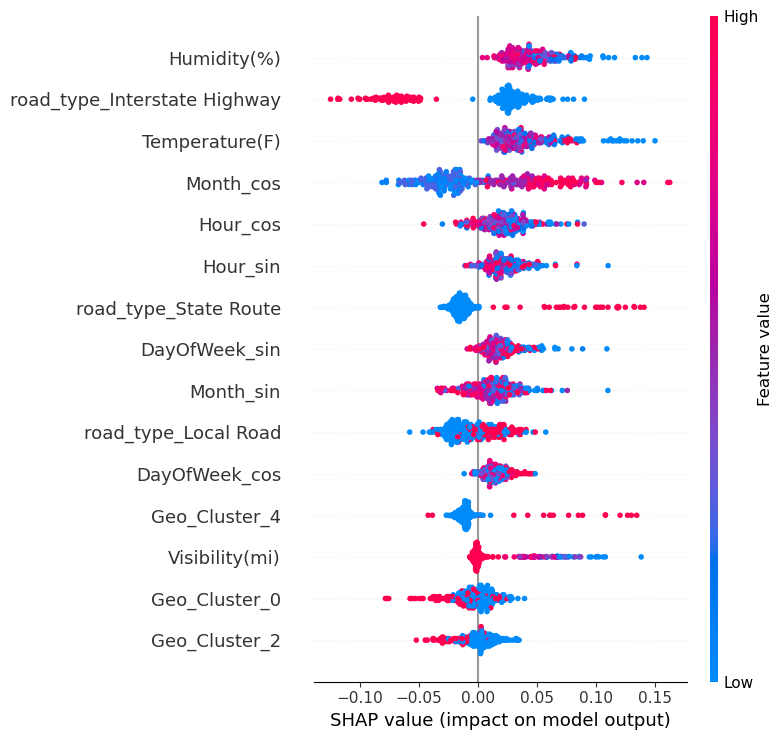

Severity 3  (balanced sample)


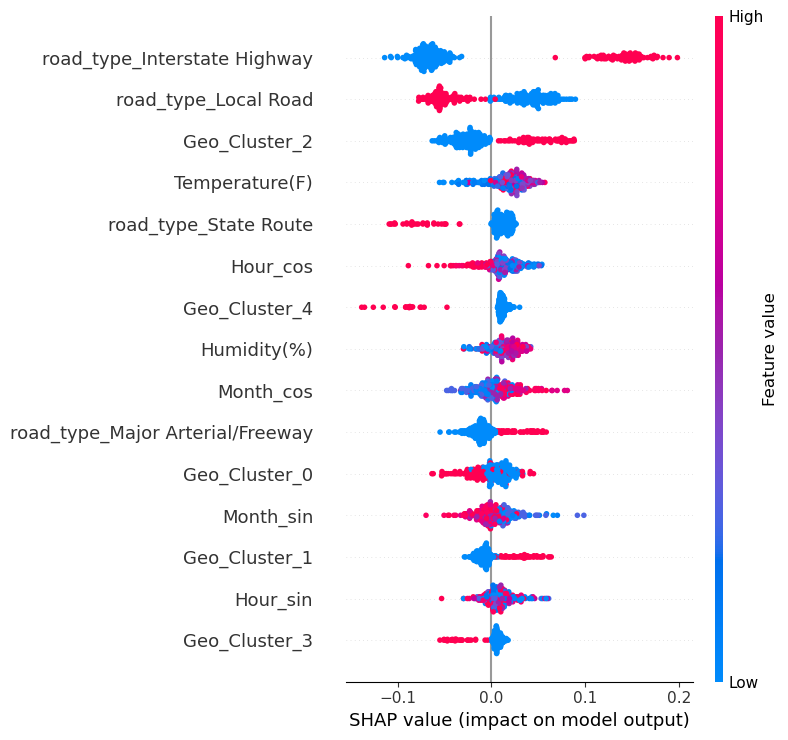

Severity 4  (balanced sample)


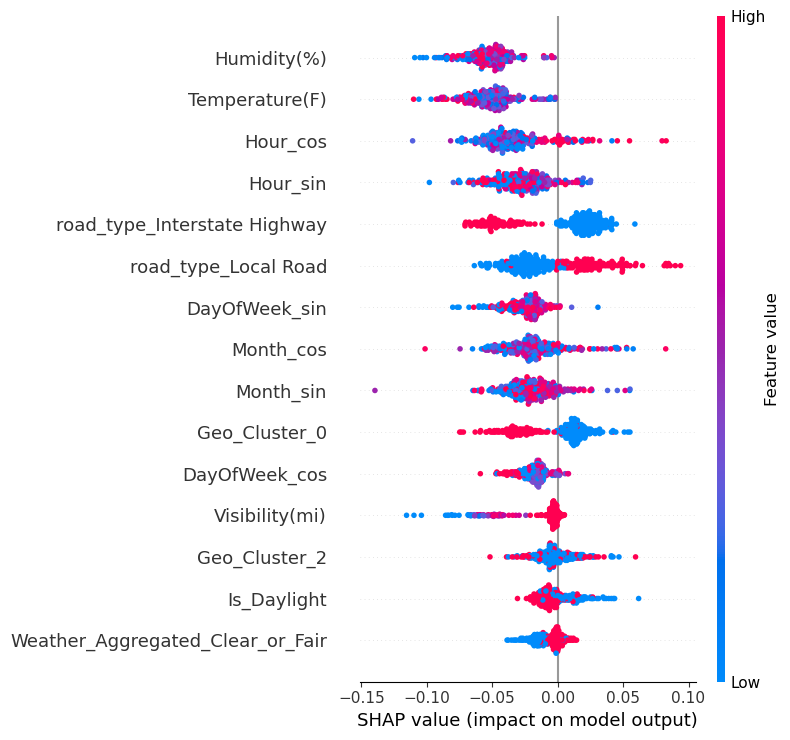

In [9]:
for cls in range(4):
    print(f"{CLASS_NAMES[cls]}  (balanced sample)")
    shap.summary_plot(
        shap_balanced[:, :, cls],
        X_shap_balanced,
        feature_names=feature_names,
        plot_type="dot",
        max_display=15,
        show=True,
    )

## Step 7 — Dependence Plots (Top 5 Features)

Shows how a single feature's value affects its SHAP value. The color shows the interaction with the most correlated other feature (chosen automatically by SHAP).

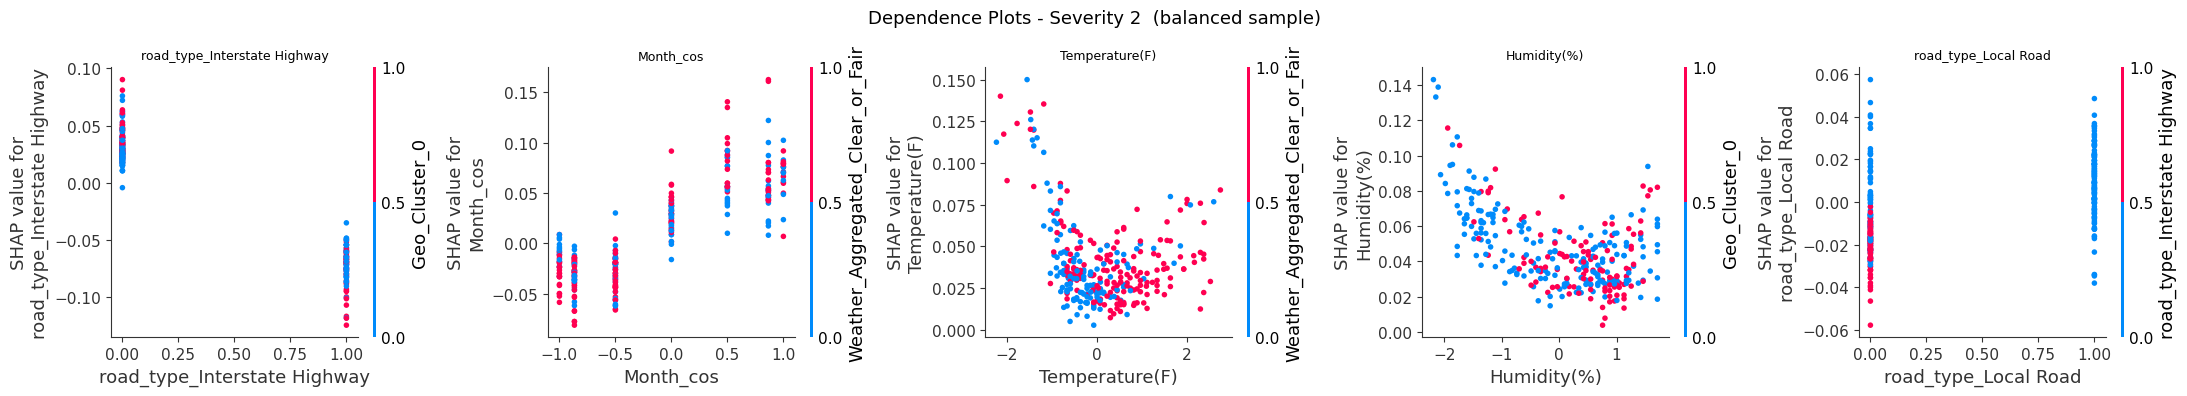

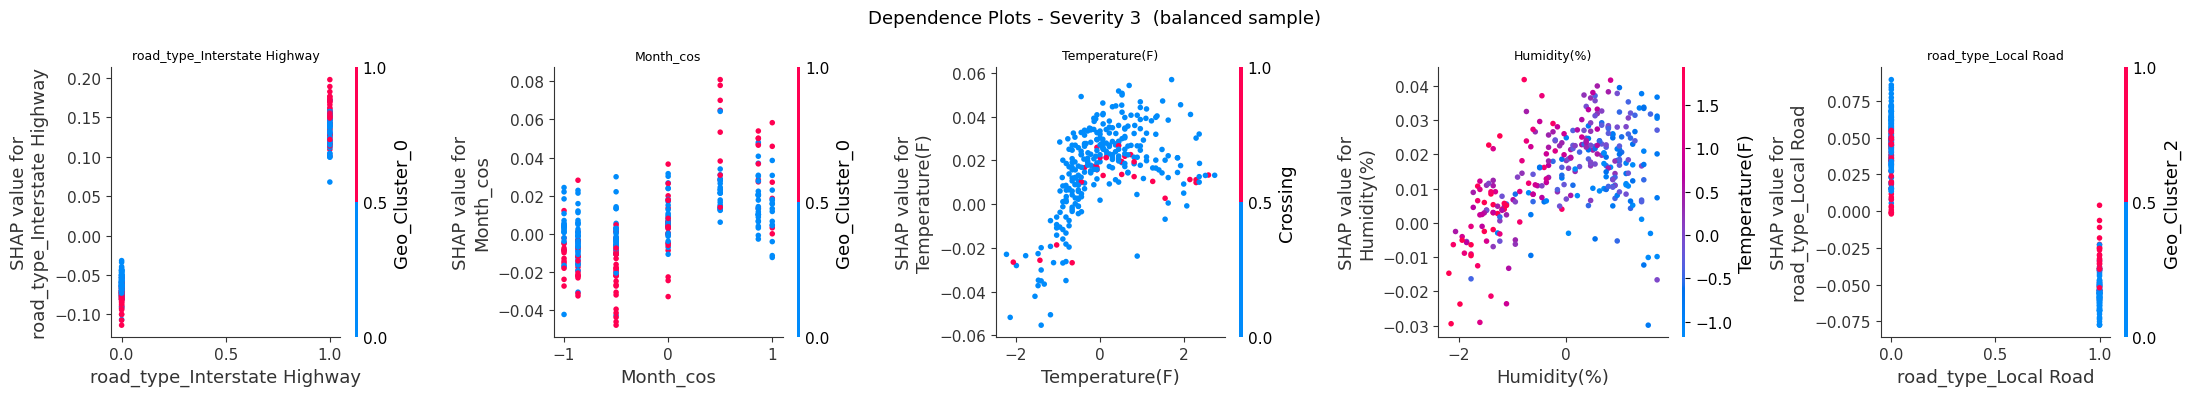

In [10]:
top5_features = importance_df["feature"].head(5).tolist()

for cls, cls_name in [(1, "Severity 2"), (2, "Severity 3")]:
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(f"Dependence Plots - {cls_name}  (balanced sample)", fontsize=13)
    for ax, feat in zip(axes, top5_features):
        shap.dependence_plot(
            feat,
            shap_balanced[:, :, cls],
            X_shap_balanced,
            feature_names=feature_names,
            ax=ax,
            show=False,
        )
        ax.set_title(feat, fontsize=9)
    plt.tight_layout()
    plt.show()